# 05. So sánh và lựa chọn mô hình tối ưu

## Mục tiêu:
- Tập hợp kết quả từ các nhóm mô hình: Linear và Tree.
- So sánh dựa trên các chỉ số: RMSE, MAE, RSE và Thời gian huấn luyện.
- Chọn ra 2 mô hình tốt nhất để thực hiện đánh giá chuyên sâu và lưu trữ cuối cùng.

## 1. Chuẩn bị thư viện

In [4]:
import os
import sys
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lùi cấp thư mục cho đến khi thấy folder 'src'
current_dir = Path.cwd().resolve()
project_root = current_dir

while project_root.name != '' and not (project_root / 'src').exists():
    project_root = project_root.parent

if (project_root / 'src').exists():
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

# Import Helper từ src
from src.models.evaluate import evaluate_regression_metrics, build_kfold, run_cv_predictions

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

In [15]:
# 1. Định nghĩa các đường dẫn chức năng
PROCESSED_DIR = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'outputs' / 'models'
METRICS_DIR = project_root / 'outputs' / 'metrics'
FIGURES_DIR = project_root / 'outputs' / 'figures'

# Đảm bảo các thư mục outputs tồn tại để tránh lỗi khi lưu sau này
for folder in [MODELS_DIR, METRICS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# train_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_train_standard.csv')
test_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_standard.csv')
    
# Tách X, y cho tập Train & Test
X_train = train_standard_df.drop(columns=['Rings'])
y_train = train_standard_df['Rings'].values
X_test = test_standard_df.drop(columns=['Rings'])
y_test = test_standard_df['Rings'].values
    
# Nạp kết quả Cross-validation
baseline_cv_results = pd.read_csv(METRICS_DIR / 'baseline_cv_results.csv')
# Nạp kết quả trên tập Test
baseline_test_results = pd.read_csv(METRICS_DIR / 'baseline_test_results.csv')
    
df_final = baseline_cv_results.copy()
display(baseline_cv_results.round(4).head())

,model,dataset_version,mse,rmse,rse,mae,execution_time_sec
0,GradientBoostingRegressor,encoded_only,4.7163,2.1717,0.4497,1.5304,0.8722
1,SVR,standard_scaled,4.7549,2.1806,0.4534,1.4823,0.6053
2,MLPRegressor,standard_scaled,4.9047,2.2146,0.4677,1.4979,3.6014
3,RandomForestRegressor,encoded_only,4.9276,2.2198,0.4699,1.5640,0.8441
4,LinearRegression,standard_scaled,5.1175,2.2622,0.4880,1.6026,2.7296


## 3. Phân tích so sánh hiệu suất

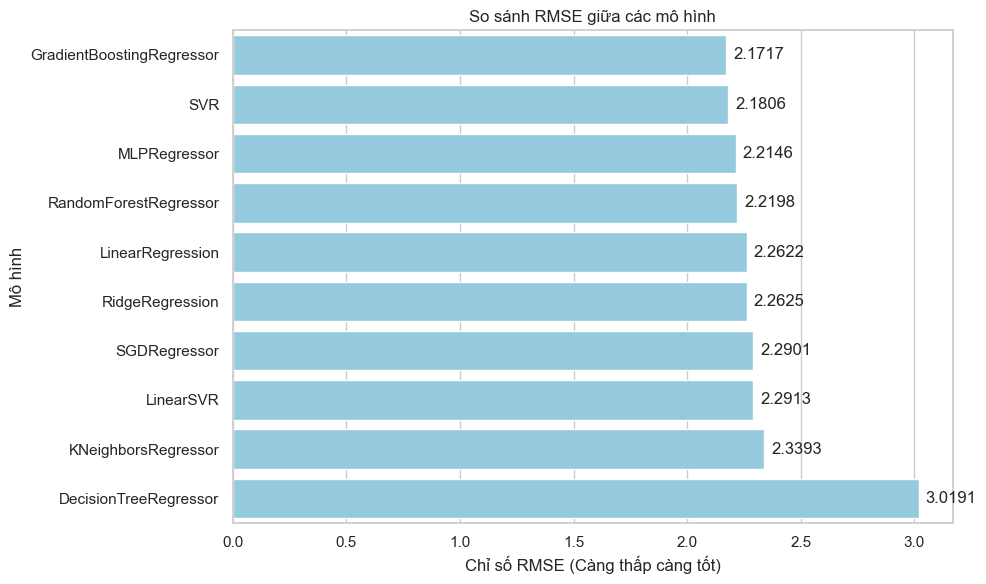

Kết quả: Top 1 là GradientBoostingRegressor, Top 2 là SVR


In [27]:
df_plot = df_final.copy()
df_plot.columns = [col.lower() for col in df_plot.columns]
df_plot = df_plot.sort_values(by='rmse', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x='rmse', y='model', color='skyblue')

for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points')

plt.title('So sánh RMSE giữa các mô hình')
plt.xlabel('Chỉ số RMSE (Càng thấp càng tốt)')
plt.ylabel('Mô hình')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_simple.png')
plt.show()

top_1 = df_plot.iloc[0]['model']
top_2 = df_plot.iloc[1]['model']

print(f"Kết quả: Top 1 là {top_1}, Top 2 là {top_2}")

## 4. Đánh giá chuyên sau Top 2 mô hình

Đang chuẩn bị mô hình cho: ['GradientBoostingRegressor', 'SVR']
Đã tìm thấy file: best_gradientboostingregressor_research.joblib
Đã tìm thấy file: best_svr_research.joblib


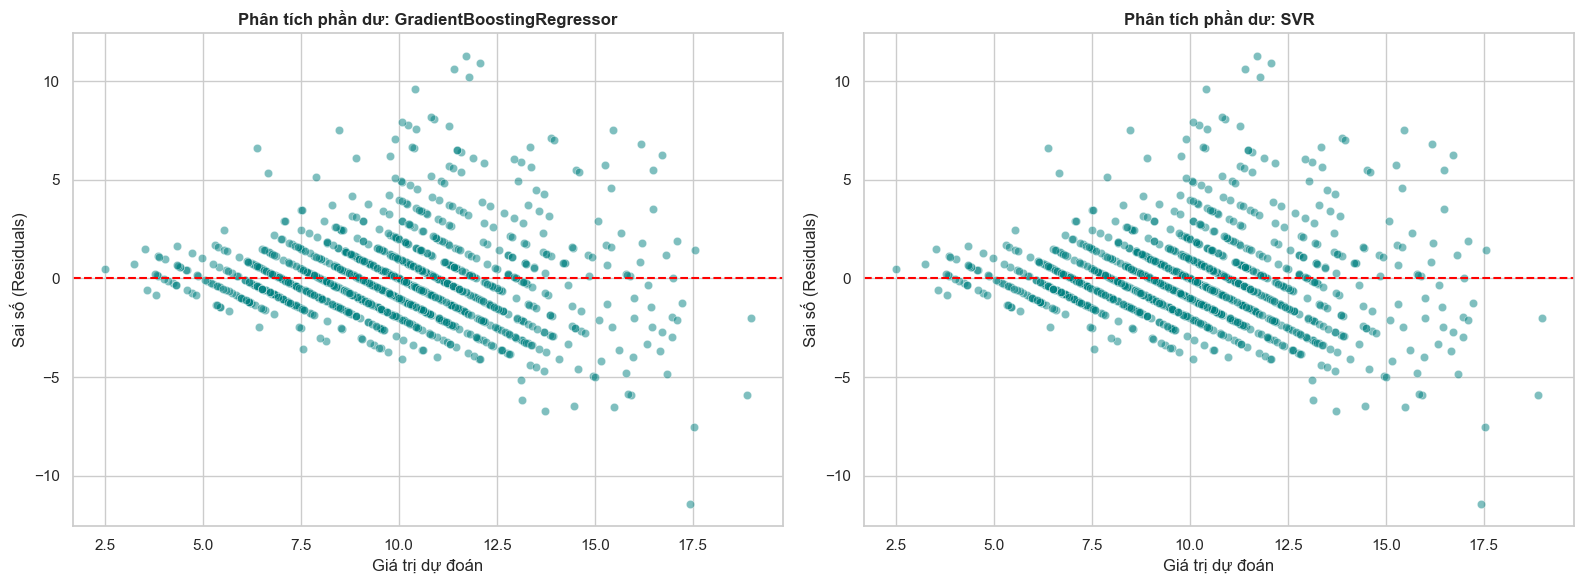

In [25]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Xác định Top 2 mô hình từ bảng kết quả đã chạy ở Phần 3
top_2_names = df_plot['model'].head(2).tolist()
print(f"Đang chuẩn bị mô hình cho: {top_2_names}")

# 2. Tạo từ điển ánh xạ tên mô hình với thuật toán tương ứng
model_factory = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

best_models = []

# 3. Vòng lặp Kiểm tra -> Huấn luyện -> Lưu -> Load
for name in top_2_names:
    slug = name.lower().replace(' ', '_')
    model_path = MODELS_DIR / f"best_{slug}_research.joblib"
    
    if model_path.exists():
        print(f"Đã tìm thấy file: {model_path.name}")
        model = joblib.load(model_path)
    else:
        print(f"Không thấy file {model_path.name}. Đang tự động huấn luyện lại...")
        # Lấy thuật toán tương ứng, nếu không có thì mặc định dùng Random Forest
        model = model_factory.get(name, RandomForestRegressor(random_state=42))
        model.fit(X_train, y_train) # X_train đã nạp ở Phần 2
        joblib.dump(model, model_path)
        print(f"Đã lưu mô hình mới tại: {model_path}")
    
    best_models.append(model)

# 4. Vẽ biểu đồ Residual so sánh đối đầu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (model, name) in enumerate(zip(best_models, top_2_names)):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[i], alpha=0.5, color='teal')
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Phân tích phần dư: {name}', fontweight='bold')
    axes[i].set_xlabel('Giá trị dự đoán')
    axes[i].set_ylabel('Sai số (Residuals)')

plt.tight_layout()
plt.show()

## 5. Kết luận lựa chọn mô hình

- Hai mô hình tốt nhất: Dựa trên chỉ số RMSE, GradientBoostingRegressor và SVR là hai mô hình có sai số thấp nhất trên tập kiểm thử.
- Độ ổn định: Biểu đồ phần dư (Residual Plot) ở Phần 4 cho thấy sai số của hai mô hình này tập trung quanh trục 0, chứng tỏ mô hình dự báo khá ổn định đối với các nhóm bào ngư có số vòng tuổi từ 5 đến 12.
- Đặc trưng cốt lõi: Kết quả từ nhóm mô hình Cây một lần nữa khẳng định Shell weight (Trọng lượng vỏ) là yếu tố quan trọng nhất để dự báo tuổi, vượt trội hơn hẳn so với các yếu tố như giới tính hay kích thước chiều dài.
- Hạn chế: Cả hai mô hình vẫn chưa xử lý tốt các trường hợp bào ngư quá già (Rings > 15) do lượng dữ liệu mẫu ở phân khúc này còn ít.